# Road Sign Model Training Pipeline

Trains **4 models** on the RoadSign dataset (4 classes: crosswalk, speedlimit, stop, trafficlight) using a ResNet-34 backbone with ImageNet pre-training.

| Step | Model | Output |
|------|-------|--------|
| 1 | **Base Classifier** | `road_sign_crop_resnet34.pth` |
| 2 | **Adversarially Trained** | `road_sign_crop_adv_trained.pth` |
| 3 | **Distilled Model** | `road_sign_crop_distilled.pth` |
| 4 | **Detection Network** | `road_sign_crop_detector.pth` |
| 5 | **Full Evaluation** | `results/evaluation_results.json` |

## 0 — Setup & Imports

In [1]:
import os, sys, time, json
sys.path.insert(0, os.getcwd())

import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt

from models.road_sign_classifier import RoadSignClassifier, NormalizedModel
from models.target_model import DetectorNet
from road_sign_data import (
    CLASS_NAMES, load_records, stratified_split,
    RoadSignCropDataset, DisplayTensorDataset,
)
from defenses.adversarial_training import train_adversarial_model
from defenses.defensive_distillation import train_distilled_model
from defenses.detection_network import train_detector
from evaluation.evaluator import run_full_evaluation

os.makedirs("saved_models", exist_ok=True)
os.makedirs("results", exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__}  |  Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch 2.6.0+cpu  |  Device: cpu


## 1 — Load & Inspect Dataset

Total records: 877  |  Train: 702  |  Val: 175
  crosswalk: 70
  speedlimit: 522
  stop: 61
  trafficlight: 49


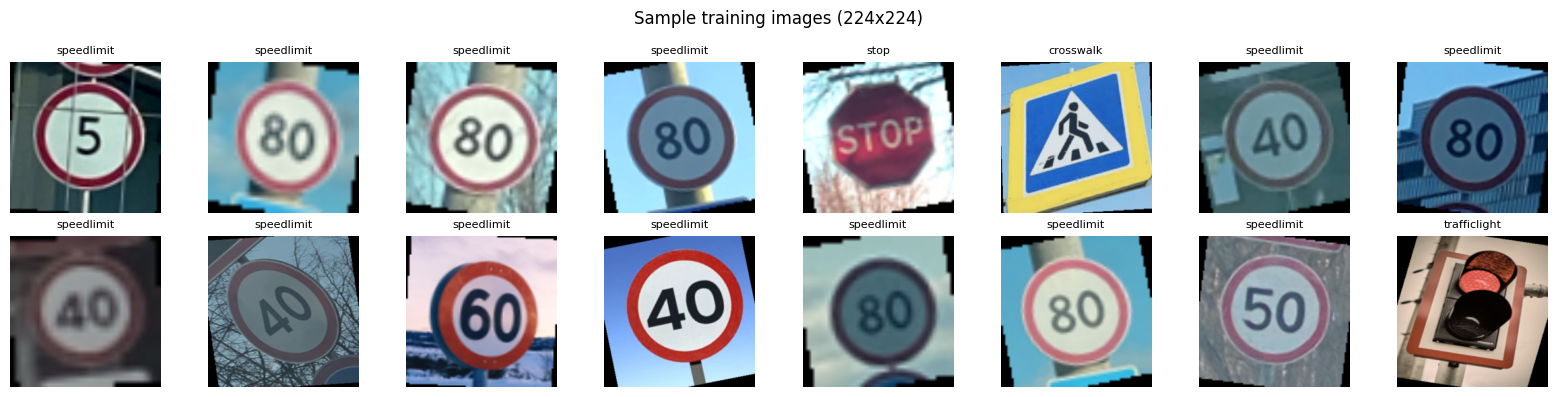

In [ ]:
BACKBONE = "resnet34"
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(CLASS_NAMES)

# ── Choose dataset: GTSRB or original ──
# Option A: GTSRB (run setup_gtsrb.ipynb first)
GTSRB_DIR = "data/GTSRB_mapped"
USE_GTSRB = os.path.exists(GTSRB_DIR)

if USE_GTSRB:
    from road_sign_data import load_records_imagefolder
    train_records = load_records_imagefolder(GTSRB_DIR, split="train")
    val_records = load_records_imagefolder(GTSRB_DIR, split="test")
    print(f"Using GTSRB dataset")
else:
    # Option B: Original annotations + images
    records = load_records("annotations", "images")
    train_records, val_records = stratified_split(records, val_ratio=0.2, seed=42)
    print(f"Using original dataset")

print(f"Train: {len(train_records)}  |  Val: {len(val_records)}")
assert len(train_records) > 0, "No training records found! Run setup_gtsrb.ipynb or check annotations/images folders."

# Normalized datasets (for base model training)
train_ds = RoadSignCropDataset(train_records, image_size=IMAGE_SIZE, augment=True, return_display=True)
val_ds = RoadSignCropDataset(val_records, image_size=IMAGE_SIZE, augment=False, return_display=True)

# Display datasets — [0,1] images for defense training
train_display_ds = DisplayTensorDataset(train_ds)
val_display_ds = DisplayTensorDataset(val_ds)

# Class distribution
from collections import Counter
label_counts = Counter(r.label for r in train_records)
for idx, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {label_counts.get(idx, 0)}")

# Visualize samples
num_samples = min(16, len(train_display_ds))
if num_samples > 0:
    cols = min(8, num_samples)
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
    axes = np.array(axes).flat if num_samples > 1 else [axes]
    for i, ax in enumerate(axes):
        if i < num_samples:
            img, label = train_display_ds[i]
            ax.imshow(img.permute(1, 2, 0).numpy())
            ax.set_title(CLASS_NAMES[label], fontsize=8)
        ax.axis("off")
    plt.suptitle("Sample training images (224x224)")
    plt.tight_layout()
    plt.show()

## 2 — Train Base Classifier (ResNet-34)

Uses pretrained ImageNet weights, balanced sampling, and class-weighted CE loss.

In [ ]:
BASE_EPOCHS = 10
BASE_LR = 3e-4
BASE_CHECKPOINT = "saved_models/road_sign_crop_resnet34.pth"

# Collate function for dict-style dataset
def collate_batch(batch):
    return {
        "image": torch.stack([item["image"] for item in batch]),
        "label": torch.stack([item["label"] for item in batch]),
    }

# Balanced sampler
counts = {idx: 0 for idx in range(NUM_CLASSES)}
for r in train_records:
    counts[r.label] += 1
sample_weights = [1.0 / max(counts[r.label], 1) for r in train_records]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# Class weights for loss — always define this (needed by adv training cell)
total = sum(counts.values())
cw = [total / max(counts[i], 1) for i in range(NUM_CLASSES)]
cw_tensor = torch.tensor(cw, dtype=torch.float32, device=device)
class_weights = cw_tensor / cw_tensor.mean()
print(f"Class weights: {[round(x, 3) for x in class_weights.tolist()]}")

# Skip training if checkpoint already exists
if os.path.exists(BASE_CHECKPOINT):
    print(f"Base model already trained -- loading from {BASE_CHECKPOINT}")
    from models.road_sign_classifier import load_road_sign_classifier_checkpoint
    base_model, _ckpt = load_road_sign_classifier_checkpoint(BASE_CHECKPOINT, device=device)
    best_val_acc = _ckpt.get("metrics", {}).get("validation", {}).get("accuracy", 0) * 100
    print(f"  Val accuracy: {best_val_acc:.2f}%")
    train_losses, train_accs, val_accs = [], [], []
else:
    base_train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                                   num_workers=0, collate_fn=collate_batch, pin_memory=False)
    base_val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=0, collate_fn=collate_batch, pin_memory=False)

    base_model = RoadSignClassifier(num_classes=NUM_CLASSES, backbone=BACKBONE, pretrained=True).to(device)
    optimizer = optim.AdamW(base_model.parameters(), lr=BASE_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=BASE_EPOCHS)

    train_losses, train_accs, val_accs = [], [], []
    best_val_acc = -1.0
    t0 = time.time()

    for epoch in range(1, BASE_EPOCHS + 1):
        base_model.train()
        total_loss, correct, total = 0, 0, 0
        for batch in base_train_loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = base_model(images)
            loss = F.cross_entropy(logits, labels, weight=class_weights)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
        scheduler.step()

        base_model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for batch in base_val_loader:
                images = batch["image"].to(device)
                labels = batch["label"].to(device)
                preds = base_model(images).argmax(1)
                v_correct += (preds == labels).sum().item()
                v_total += labels.size(0)

        t_acc = 100.0 * correct / total
        v_acc = 100.0 * v_correct / v_total
        avg_loss = total_loss / total
        train_losses.append(avg_loss)
        train_accs.append(t_acc)
        val_accs.append(v_acc)

        if v_acc >= best_val_acc:
            best_val_acc = v_acc
            torch.save({
                "model_state": base_model.state_dict(),
                "epoch": epoch,
                "metrics": {"train": {"accuracy": t_acc / 100}, "validation": {"accuracy": v_acc / 100}},
                "class_names": CLASS_NAMES,
                "config": {"num_classes": NUM_CLASSES, "backbone": BACKBONE, "image_size": IMAGE_SIZE, "padding_ratio": 0.2},
            }, BASE_CHECKPOINT)

        if epoch % 2 == 0 or epoch == 1:
            print(f"  Epoch {epoch:02d}/{BASE_EPOCHS}  Loss={avg_loss:.4f}  Train={t_acc:.1f}%  Val={v_acc:.1f}%{'  *best*' if v_acc >= best_val_acc else ''}")

    print(f"\nDone in {time.time()-t0:.0f}s  |  Best val acc: {best_val_acc:.2f}%")
    print(f"Saved: {BASE_CHECKPOINT}")

In [ ]:
# Plot training curves (skip if loaded from checkpoint)
if train_losses:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs_range = range(1, len(train_losses) + 1)
    ax1.plot(epochs_range, train_losses, "o-", color="#e74c3c", linewidth=2, markersize=3)
    ax1.set_title("Training Loss", fontweight="bold"); ax1.set_xlabel("Epoch"); ax1.grid(alpha=0.3)
    ax2.plot(epochs_range, train_accs, "o-", color="#3498db", linewidth=2, markersize=3, label="Train")
    ax2.plot(epochs_range, val_accs, "s-", color="#2ecc71", linewidth=2, markersize=3, label="Val")
    ax2.set_title("Accuracy", fontweight="bold"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("%"); ax2.legend(); ax2.grid(alpha=0.3)
    fig.suptitle("Base Model Training Curves", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("Loaded from checkpoint -- no training curves to plot.")

## 3 — Adversarial Training (PGD)

Trains a fresh ResNet-34 on PGD adversarial examples. Uses `NormalizedModel` wrapper so PGD operates in [0,1] pixel space.

In [ ]:
ADV_EPOCHS = 5
ADV_EPSILON = 8 / 255
ADV_ALPHA = 2 / 255
ADV_PGD_STEPS = 7
ADV_LR = 1e-4
ADV_CHECKPOINT = "saved_models/road_sign_crop_adv_trained.pth"

# Defense data loader — yields (display_image, label) tuples in [0,1]
defense_train_loader = DataLoader(train_display_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# Model factory: NormalizedModel(pretrained ResNet-34)
def adv_model_factory():
    clf = RoadSignClassifier(num_classes=NUM_CLASSES, backbone=BACKBONE, pretrained=True)
    return NormalizedModel(clf)

# Move class_weights to the right device for the defense module
adv_class_weights = class_weights.to(device)

t0 = time.time()
adv_model = train_adversarial_model(
    model_factory=adv_model_factory,
    train_loader=defense_train_loader,
    epsilon=ADV_EPSILON,
    alpha=ADV_ALPHA,
    pgd_steps=ADV_PGD_STEPS,
    epochs=ADV_EPOCHS,
    lr=ADV_LR,
    device=device,
    class_weights=adv_class_weights,
)
print(f"\nDone in {time.time()-t0:.0f}s")

# Save (unwrap NormalizedModel -> save inner classifier state)
inner_model = adv_model.model
torch.save({
    "model_state": inner_model.state_dict(),
    "epoch": ADV_EPOCHS,
    "metrics": {},
    "class_names": CLASS_NAMES,
    "config": {"num_classes": NUM_CLASSES, "backbone": BACKBONE, "image_size": IMAGE_SIZE, "padding_ratio": 0.2},
}, ADV_CHECKPOINT)
print(f"Saved: {ADV_CHECKPOINT}")

NameError: name 'class_weights' is not defined

## 4 — Defensive Distillation

Uses the base model as teacher to train a student with temperature-scaled soft labels.

In [ ]:
DISTILL_EPOCHS = 5
DISTILL_TEMPERATURE = 20.0
DISTILL_ALPHA = 0.7
DISTILL_LR = 1e-4
DISTILL_CHECKPOINT = "saved_models/road_sign_crop_distilled.pth"

# Wrap base model as teacher (NormalizedModel so it accepts [0,1] images)
from models.road_sign_classifier import load_road_sign_classifier_checkpoint
teacher_clf, _ = load_road_sign_classifier_checkpoint(BASE_CHECKPOINT, device=device)
teacher = NormalizedModel(teacher_clf).to(device)
teacher.eval()

def distill_model_factory():
    clf = RoadSignClassifier(num_classes=NUM_CLASSES, backbone=BACKBONE, pretrained=True)
    return NormalizedModel(clf)

t0 = time.time()
distilled_model = train_distilled_model(
    teacher_model=teacher,
    model_factory=distill_model_factory,
    train_loader=defense_train_loader,
    temperature=DISTILL_TEMPERATURE,
    alpha=DISTILL_ALPHA,
    epochs=DISTILL_EPOCHS,
    lr=DISTILL_LR,
    device=device,
)
print(f"\nDone in {time.time()-t0:.0f}s")

# Save
inner_model = distilled_model.model
torch.save({
    "model_state": inner_model.state_dict(),
    "epoch": DISTILL_EPOCHS,
    "metrics": {},
    "class_names": CLASS_NAMES,
    "config": {"num_classes": NUM_CLASSES, "backbone": BACKBONE, "image_size": IMAGE_SIZE, "padding_ratio": 0.2},
}, DISTILL_CHECKPOINT)
print(f"Saved: {DISTILL_CHECKPOINT}")

## 5 — Detection Network

Binary classifier on ResNet-34 features (dim=512) to distinguish clean vs adversarial inputs.

In [ ]:
DET_EPOCHS = 5
DET_EPSILON = 8 / 255
DET_LR = 1e-3
DET_CHECKPOINT = "saved_models/road_sign_crop_detector.pth"

# Use NormalizedModel base for feature extraction (attacks operate on [0,1])
base_normalized = NormalizedModel(teacher_clf).to(device)
base_normalized.eval()

detector = DetectorNet(input_dim=teacher_clf.feature_dim)

t0 = time.time()
detector = train_detector(
    target_model=base_normalized,
    detector_model=detector,
    train_loader=defense_train_loader,
    epsilon=DET_EPSILON,
    epochs=DET_EPOCHS,
    lr=DET_LR,
    device=device,
)
print(f"\nDone in {time.time()-t0:.0f}s")

torch.save(detector.state_dict(), DET_CHECKPOINT)
print(f"Saved: {DET_CHECKPOINT}")

## 6 — Clean Accuracy Comparison

In [ ]:
defense_val_loader = DataLoader(val_display_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

def clean_accuracy(model, loader, device):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(1) == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total

# Load all models as NormalizedModel for fair comparison
models_to_eval = {
    "Base": NormalizedModel(teacher_clf).to(device),
    "Adv Trained": adv_model.to(device),
    "Distilled": distilled_model.to(device),
}

accs = {}
for name, model in models_to_eval.items():
    acc = clean_accuracy(model, defense_val_loader, device)
    accs[name] = acc
    print(f"  {name:15s}  {acc:.2f}%")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#3498db", "#e74c3c", "#2ecc71"]
bars = ax.bar(accs.keys(), accs.values(), color=colors, width=0.5)
ax.set_ylim(max(0, min(accs.values()) - 10), 100)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Clean Validation Accuracy", fontweight="bold")
for b, v in zip(bars, accs.values()):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 7 — Full Evaluation (4 attacks x 5 defenses)

Runs FGSM, PGD, Genetic Algorithm, and Differential Evolution attacks against all defense strategies.

In [ ]:
EVAL_EPSILON = 8 / 255
EVAL_SAMPLES = 30

models_dict = {
    "base": models_to_eval["Base"],
    "adv_trained": models_to_eval["Adv Trained"],
    "distilled": models_to_eval["Distilled"],
    "detector": detector,
}

t0 = time.time()
eval_results = run_full_evaluation(
    models_dict=models_dict,
    test_loader=defense_val_loader,
    epsilon=EVAL_EPSILON,
    num_samples=EVAL_SAMPLES,
    device=device,
    save_path="results/evaluation_results.json",
)
print(f"\nEvaluation done in {time.time()-t0:.0f}s")

In [ ]:
# Heatmap: Attack Success Rate
with open("results/evaluation_results.json") as f:
    results = json.load(f)

atk_names = results["attack_names"]
def_names = results["defense_names"]
matrix = results["results"]
atk_keys = list(atk_names.keys())
def_keys = list(def_names.keys())

asr = np.zeros((len(atk_keys), len(def_keys)))
for i, ak in enumerate(atk_keys):
    for j, dk in enumerate(def_keys):
        asr[i, j] = matrix.get(ak, {}).get(dk, {}).get("attack_success_rate", 0)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(asr, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(def_keys)))
ax.set_xticklabels([def_names[k] for k in def_keys], rotation=25, ha="right")
ax.set_yticks(range(len(atk_keys)))
ax.set_yticklabels([atk_names[k] for k in atk_keys])
for i in range(len(atk_keys)):
    for j in range(len(def_keys)):
        c = "white" if asr[i, j] > 60 else "black"
        ax.text(j, i, f"{asr[i,j]:.1f}%", ha="center", va="center", fontweight="bold", color=c, fontsize=10)
ax.set_title("Attack Success Rate (%) — Lower = Better Defense", fontsize=13, fontweight="bold", pad=12)
plt.colorbar(im, ax=ax, label="ASR (%)")
plt.tight_layout(); plt.show()

## Summary

All models and evaluation results saved:
- `saved_models/road_sign_crop_resnet34.pth` — Base classifier
- `saved_models/road_sign_crop_adv_trained.pth` — Adversarially trained
- `saved_models/road_sign_crop_distilled.pth` — Distilled model
- `saved_models/road_sign_crop_detector.pth` — Detection network
- `results/evaluation_results.json` — Full evaluation matrix

**Next:** Run `python app.py` to launch the interactive dashboard.